# protGPS on CMC (COSMIC Cancer Mutation Census): condensate localization variant effects

Same analysis as `protgps_clinvar_exploration.ipynb`, applied to the CMC somatic mutation set. Loads the merged wild-type vs. mutant protGPS predictions (`cmc_protgps_deltas_rbp.tsv`, built by `../12_variant_effect_prediction/localization_condensate/`).

**Data file is not checked into git** — regenerate via the pipeline in `12_variant_effect_prediction/localization_condensate/`, or pull `cmc_protgps_deltas_rbp.tsv` from `/u/project/kappel/ddcohn/protein_variant_effects/` on Hoffman2.

Note: CMC uses Ensembl transcript IDs (`ENST...`), not RefSeq (`NM_...`) like ClinVar — different accession namespace, same gene symbols where they overlap.

**RBP-only version.** Filtered to the 2,215-gene RNA-binding-protein list in `../12_variant_effect_prediction/rbp_filter/rbp_gene_symbols.txt` (union of a classic-RNA-binding-domain list and RBP2GO's high-confidence human RBP dataset -- see that folder's README for the full method). The genome-wide version of this notebook is `protgps_cmc_exploration.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
PALETTE = ["#8ecae6", "#219ebc", "#023047", "#ffb703", "#fb8500"]
sns.set_palette(PALETTE)

COMPARTMENTS = [
    "NUCLEAR_SPECKLE", "P-BODY", "PML-BDOY", "POST_SYNAPTIC_DENSITY",
    "STRESS_GRANULE", "CHROMOSOME", "NUCLEOLUS", "NUCLEAR_PORE_COMPLEX",
    "CAJAL_BODY", "RNA_GRANULE", "CELL_JUNCTION", "TRANSCRIPTIONAL",
]

## Load data

In [2]:
df = pd.read_csv("cmc_protgps_deltas_rbp.tsv", sep="\t")
print(f"{len(df):,} variant rows")
df.head()

372,819 variant rows


,GENOMIC_MUTATION_ID,GENE_NAME,accession,category,WT_NUCLEAR_SPECKLE,WT_P-BODY,WT_PML-BDOY,WT_POST_SYNAPTIC_DENSITY,WT_STRESS_GRANULE,WT_CHROMOSOME,...,DELTA_PML-BDOY,DELTA_POST_SYNAPTIC_DENSITY,DELTA_STRESS_GRANULE,DELTA_CHROMOSOME,DELTA_NUCLEOLUS,DELTA_NUCLEAR_PORE_COMPLEX,DELTA_CAJAL_BODY,DELTA_RNA_GRANULE,DELTA_CELL_JUNCTION,DELTA_TRANSCRIPTIONAL
0,COSV51273354,EPHA8,ENST00000166244,missense,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0003,0.0,0.0,0.0000,0.0
1,COSV51266607,EPHA8,ENST00000166244,missense,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0008,0.0,0.0,0.0001,0.0
2,COSV51293908,EPHA8,ENST00000166244,missense,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0024,0.0,0.0,0.0000,0.0
3,COSV51268352,EPHA8,ENST00000166244,missense,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.0002,0.0,0.0,0.0001,0.0
4,COSV51278691,EPHA8,ENST00000166244,missense,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0001,0.0


## Sanity check: same known condensate marker genes as the ClinVar notebook

Same five genes, looked up via their CMC/Ensembl transcript IDs this time. Should reproduce the same pattern seen in ClinVar (4/5 correct, NPM1 mismatched) since it's the same WT protein sequence and the same model -- a useful cross-dataset consistency check.

In [3]:
known_genes = {
    "COIL": "CAJAL_BODY",
    "FUS": "STRESS_GRANULE",
    "G3BP1": "STRESS_GRANULE",
    "TARDBP": "STRESS_GRANULE",
}
# NPM1 (used in the genome-wide version) isn't in the RBP gene list, dropped here.

wt_cols = [f"WT_{c}" for c in COMPARTMENTS]
for gene, expected in known_genes.items():
    rows = df[df["GENE_NAME"] == gene]
    if rows.empty:
        print(f"{gene}: no variant rows in this table")
        continue
    acc = rows.iloc[0]["accession"]
    wt_scores = rows.iloc[0][wt_cols]
    top = wt_scores.astype(float).idxmax().replace("WT_", "")
    top_score = wt_scores.astype(float).max()
    match = "OK" if top == expected else "MISMATCH"
    print(f"{gene:8s} ({acc}): top={top:22s} ({top_score:.3f})  expected={expected:15s}  [{match}]")

COIL     (ENST00000240316): top=CAJAL_BODY             (0.992)  expected=CAJAL_BODY       [OK]
FUS      (ENST00000254108): top=STRESS_GRANULE         (0.874)  expected=STRESS_GRANULE   [OK]
G3BP1    (ENST00000394123): top=STRESS_GRANULE         (0.997)  expected=STRESS_GRANULE   [OK]
TARDBP   (ENST00000240185): top=STRESS_GRANULE         (0.997)  expected=STRESS_GRANULE   [OK]


## Wild-type score distributions

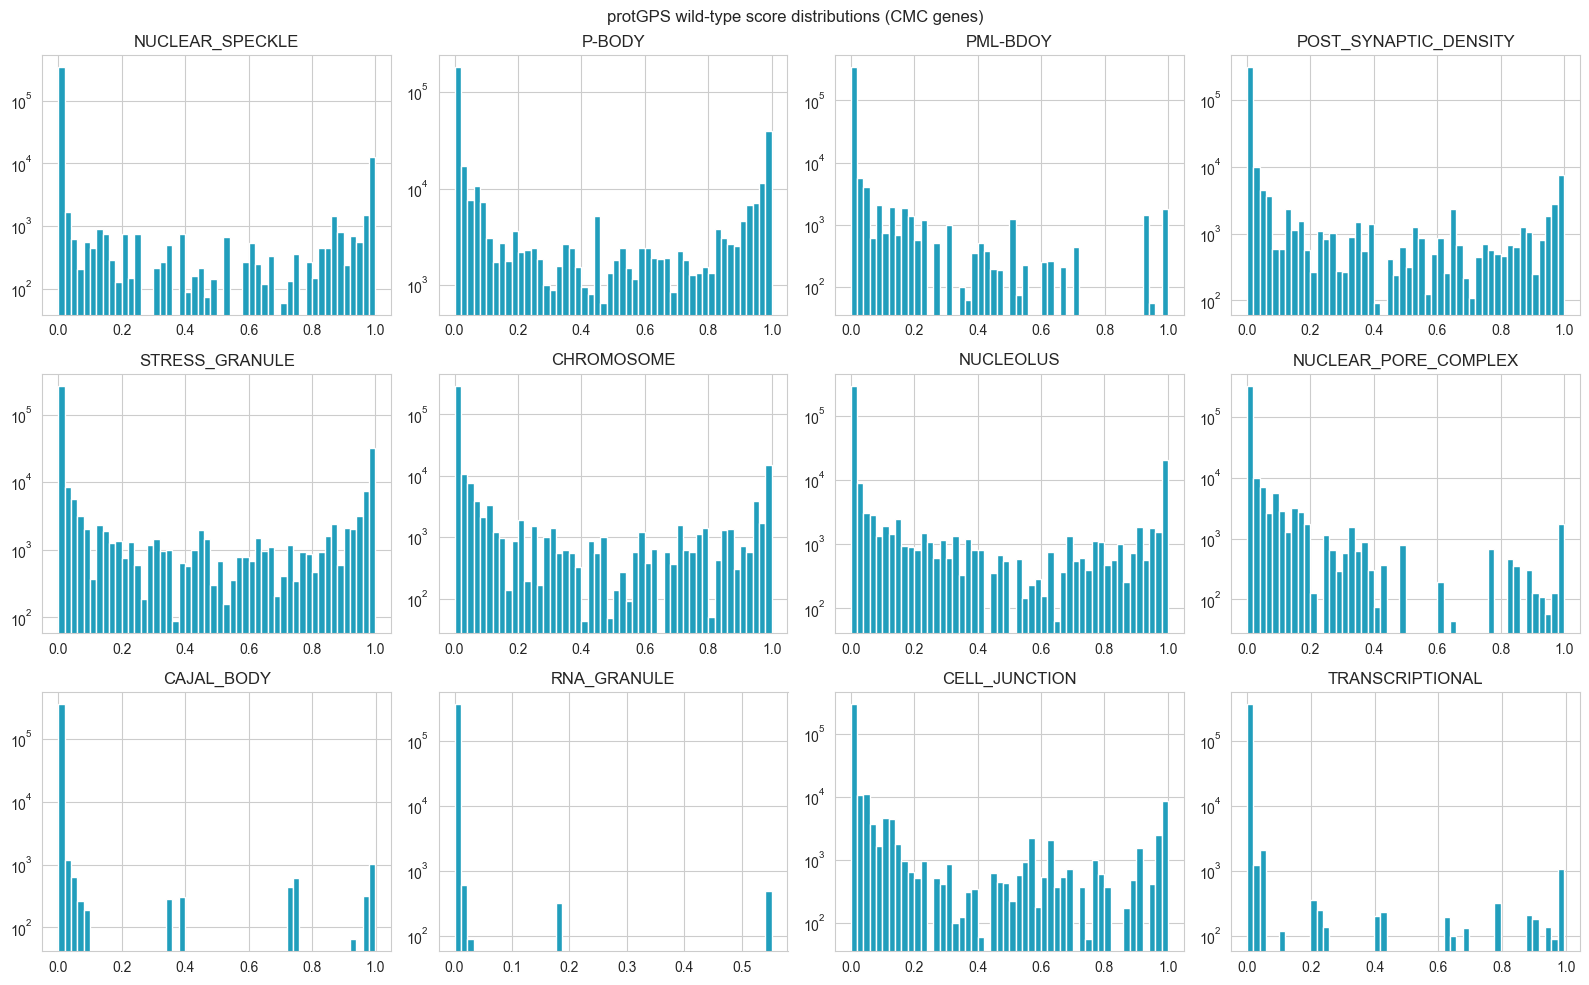

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, c in zip(axes.flat, COMPARTMENTS):
    ax.hist(df[f"WT_{c}"], bins=50, color="#219ebc")
    ax.set_yscale("log")
    ax.set_title(c)
fig.suptitle("protGPS wild-type score distributions (CMC genes)")
fig.tight_layout()
plt.show()

## Variant effect (delta) distributions

Somatic cancer mutations (CMC) vs. germline ClinVar variants -- worth comparing whether the delta distributions look similar in shape/magnitude between the two notebooks.

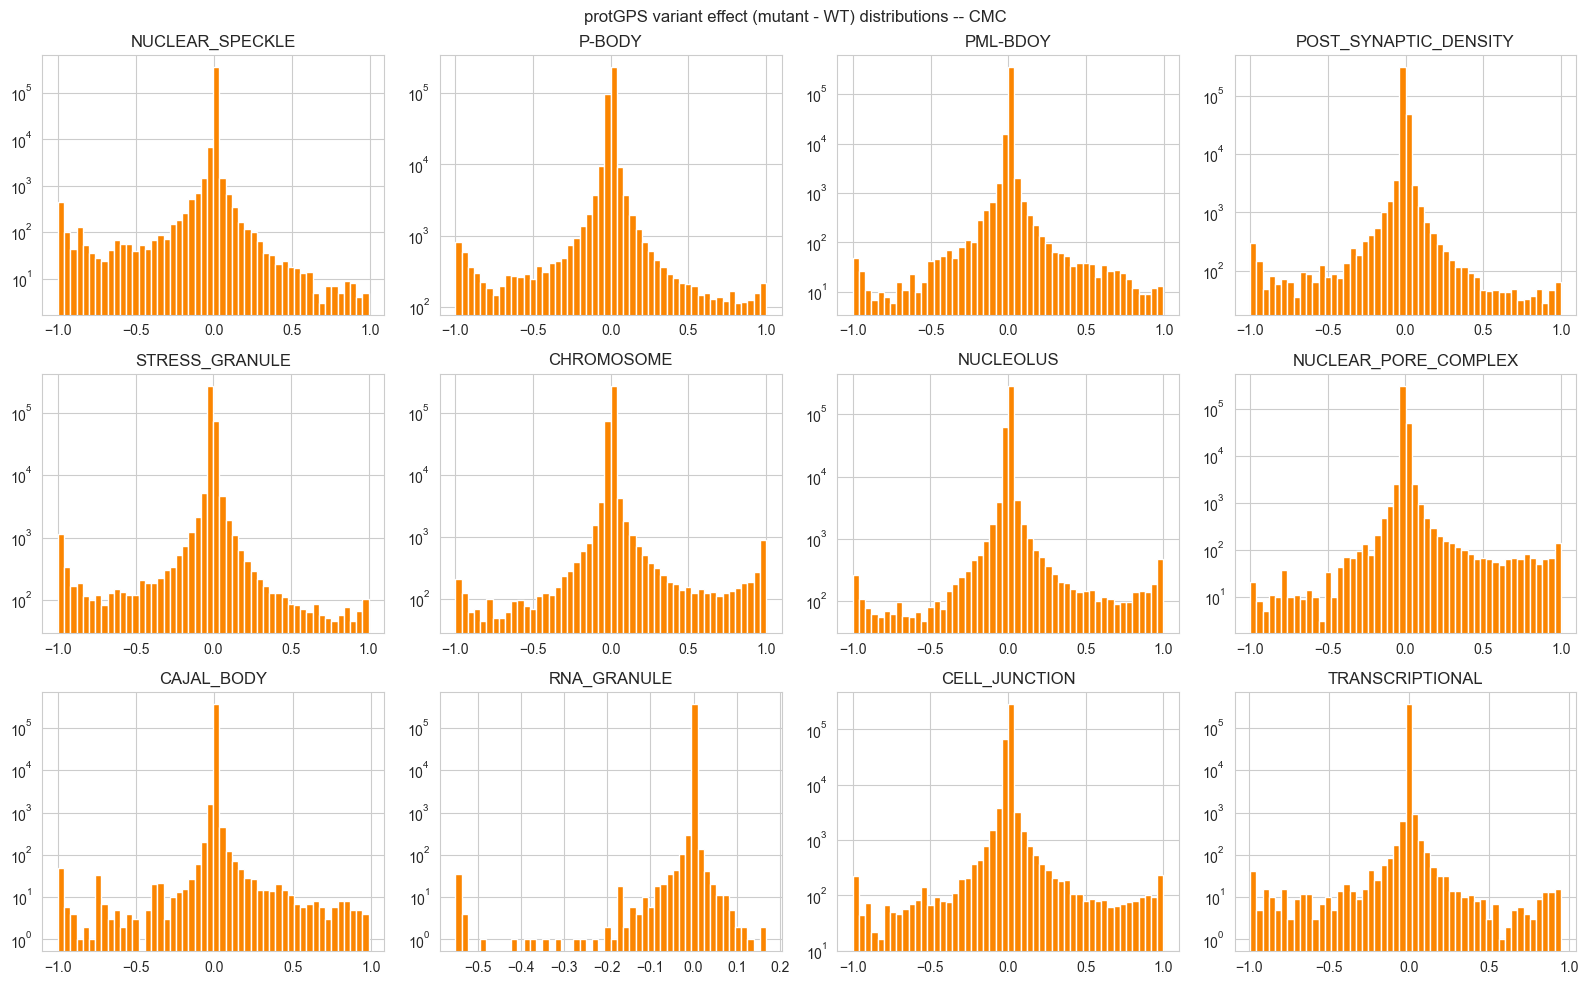

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, c in zip(axes.flat, COMPARTMENTS):
    ax.hist(df[f"DELTA_{c}"], bins=50, color="#fb8500")
    ax.set_yscale("log")
    ax.set_title(c)
fig.suptitle("protGPS variant effect (mutant - WT) distributions -- CMC")
fig.tight_layout()
plt.show()

## Variants with the largest predicted condensate-localization change

In [6]:
delta_cols = [f"DELTA_{c}" for c in COMPARTMENTS]
max_abs_delta = df[delta_cols].abs().max(axis=1)
top_variants = df.loc[max_abs_delta.sort_values(ascending=False).index[:25]]
top_variants[["GENOMIC_MUTATION_ID", "GENE_NAME", "category", "accession"] + delta_cols].head(25)

,GENOMIC_MUTATION_ID,GENE_NAME,category,accession,DELTA_NUCLEAR_SPECKLE,DELTA_P-BODY,DELTA_PML-BDOY,DELTA_POST_SYNAPTIC_DENSITY,DELTA_STRESS_GRANULE,DELTA_CHROMOSOME,DELTA_NUCLEOLUS,DELTA_NUCLEAR_PORE_COMPLEX,DELTA_CAJAL_BODY,DELTA_RNA_GRANULE,DELTA_CELL_JUNCTION,DELTA_TRANSCRIPTIONAL
328490,COSV55821060,PKP1,nonsense,ENST00000263946,0.0000,0.0003,0.0000,0.0000,0.0000,0.5216,0.0000,0.8055,0.0000,0.0,-1.0000,0.0000
46928,COSV100383568,ZCCHC7,nonsense,ENST00000336755,0.0000,0.0078,0.0000,0.0000,0.0000,0.0006,-1.0000,0.9930,0.0000,0.0,0.0025,0.0000
328277,COSV99825811,PKP1,nonsense,ENST00000263946,0.0000,0.0012,0.0004,0.0000,0.0000,0.0105,0.0000,0.0030,0.0004,0.0,-1.0000,0.0000
355904,COSV58574683,TNS2,nonsense,ENST00000314276,0.0002,0.8836,0.0000,0.0000,0.0028,0.0001,0.0353,0.0000,0.0000,0.0,-1.0000,0.0000
106980,COSV107329142,KHDRBS1,nonsense,ENST00000327300,0.0000,-0.0090,0.0000,0.0000,-0.9998,0.1218,1.0000,0.0000,0.0000,0.0,0.0000,0.0000
12587,COSV107263557,HERC5,nonsense,ENST00000264350,0.0000,-1.0000,0.0159,0.0000,-0.0001,0.9872,0.0059,0.0001,0.0000,0.0,0.0001,0.0000
356111,COSV100048888,TNS2,nonsense,ENST00000314276,0.0059,0.3957,0.0001,0.0000,0.0024,0.0008,0.2832,0.0000,0.0000,0.0,-1.0000,0.0000
241888,COSV100626256,EPHA2,nonsense,ENST00000358432,0.0000,0.0000,0.0000,0.1028,0.0000,0.0174,0.0000,0.3397,0.0000,0.0,-1.0000,0.0000
74457,COSV54680903,SSBP1,nonsense,ENST00000481508,0.0000,0.0000,0.0000,-0.2340,0.0000,0.0457,-0.0015,1.0000,0.0000,0.0,0.0000,0.0000
241718,COSV100626062,EPHA2,nonsense,ENST00000358432,0.0000,0.0000,0.0000,0.9948,0.0000,0.0000,0.0000,0.0810,0.0000,0.0,-1.0000,0.0000


## How many variants change predicted condensate localization?

protGPS gives a continuous score per compartment rather than a single predicted label, so "changed" here means the variant's largest absolute delta across the 12 compartments is >= 0.5 (the same high-confidence cutoff used elsewhere in this project). Counts, then the fraction changed by variant category.

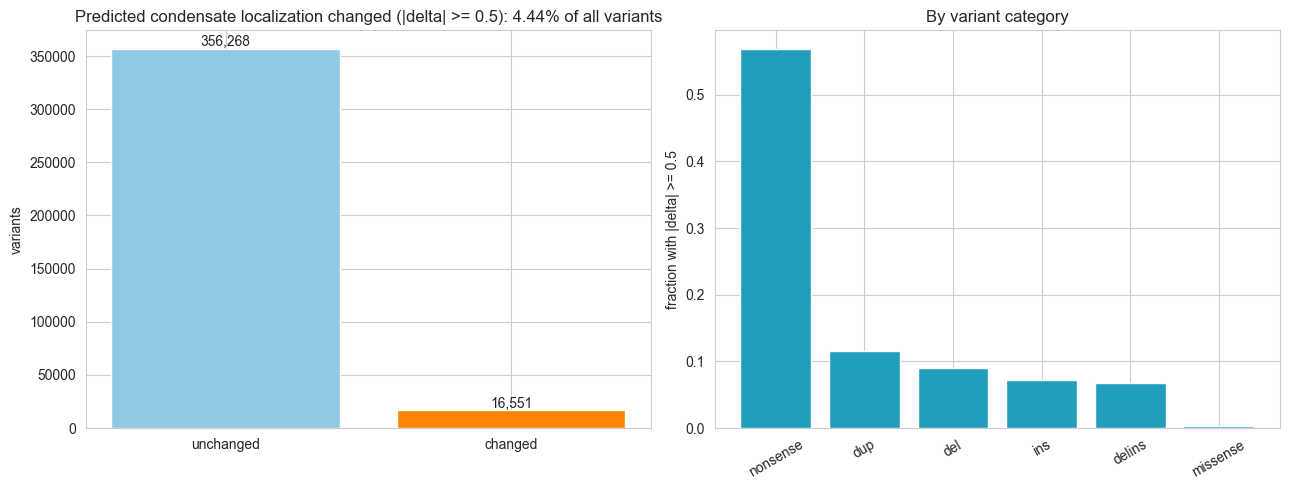

In [7]:
delta_cols = [f"DELTA_{c}" for c in COMPARTMENTS]
max_abs_delta = df[delta_cols].abs().max(axis=1)
changed = max_abs_delta >= 0.5

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = changed.map({False: "unchanged", True: "changed"}).value_counts()
axes[0].bar(counts.index, counts.values, color=[PALETTE[0], PALETTE[4]])
axes[0].set_ylabel("variants")
axes[0].set_title(f"Predicted condensate localization changed (|delta| >= 0.5): {changed.mean():.2%} of all variants")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

by_cat = pd.Series(changed).groupby(df["category"]).mean().sort_values(ascending=False)
axes[1].bar(by_cat.index, by_cat.values, color=PALETTE[1])
axes[1].set_ylabel("fraction with |delta| >= 0.5")
axes[1].set_title("By variant category")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()